### Pacotes importados

In [1]:
using LinearAlgebra
using Printf

## Chapter 11: Descent methods and line search

### Algorithm 11.2: Initialization of the exact line search 

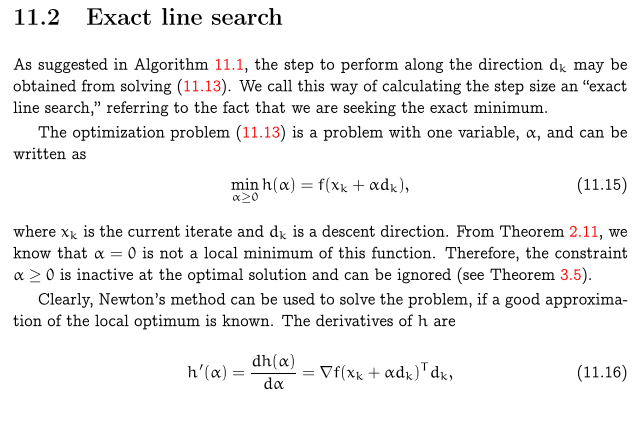

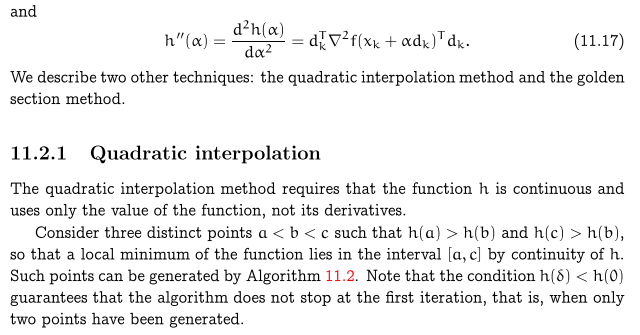

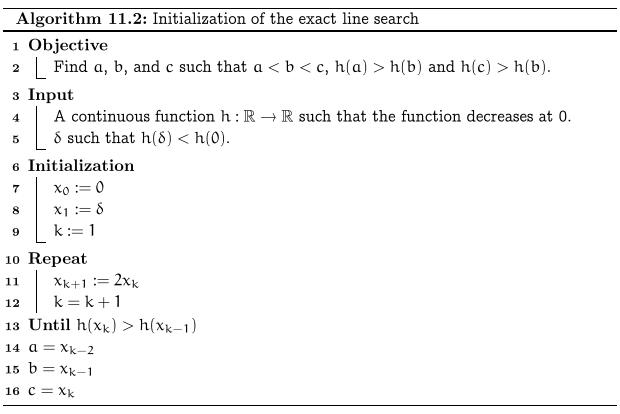

Test with Example 11.3: $h(x) = (2+x) \cos(2+x)$.

In [2]:
# Definição da função h(x)
h113(x) = (2 + x) * cos(2 + x)

function algoritmo_11_2(h, delta)
    x0 = 0.0
    x1 = delta
    k = 1
    
    # Armazenar os pontos para o loop
    xs = [x0, x1]
    
    while h(xs[end]) <= h(xs[end-1])
        push!(xs, 2 * xs[end])
        k += 1
        if k > 50 break end # Proteção
    end
    
    a = xs[end-2]
    b = xs[end-1]
    c = xs[end]
    
    @printf("Intervalo encontrado: a=%.4f, b=%.4f, c=%.4f\n", a, b, c)
    @printf("Valores: h(a)=%.4f, h(b)=%.4f, h(c)=%.4f\n", h(a), h(b), h(c))
    
    return a, b, c
end

println("Executando Inicialização (Bracketing):")
a_init, b_init, c_init = algoritmo_11_2(h113, 0.1)

Executando Inicialização (Bracketing):
Intervalo encontrado: a=0.8000, b=1.6000, c=3.2000
Valores: h(a)=-2.6382, h(b)=-3.2283, h(c)=2.4363


(0.8, 1.6, 3.2)

### Algorithm 11.3: Exact line search: quadratic interpolation

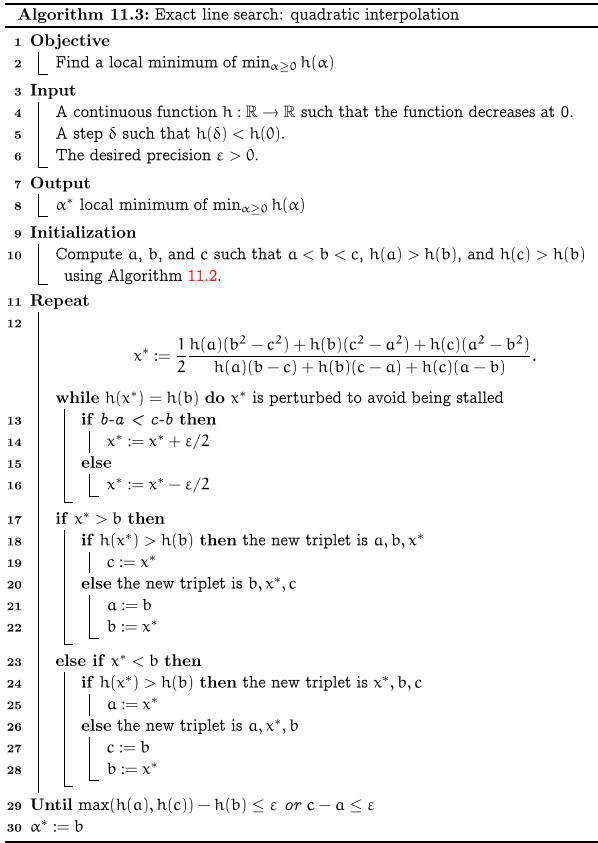

Test with Example 11.3: $h(x) = (2+x) \cos(2+x)$.

In [3]:
function algoritmo_11_3(h, delta, eps)
    # Passo 1: Inicialização
    a, b, c = algoritmo_11_2(h, delta)
    
    k = 0
    while (max(h(a), h(c)) - h(b) > eps) && (c - a > eps)
        # Fórmula da Interpolação Quadrática para o vértice x*
        num = h(a)*(b^2 - c^2) + h(b)*(c^2 - a^2) + h(c)*(a^2 - b^2)
        den = 2 * (h(a)*(b - c) + h(b)*(c - a) + h(c)*(a - b))
        
        x_star = num / den
        
        # Lógica de atualização do triplo (a, b, c)
        if x_star > b
            if h(x_star) > h(b)
                c = x_star
            else
                a = b; b = x_star
            end
        else
            if h(x_star) > h(b)
                a = x_star
            else
                c = b; b = x_star
            end
        end
        k += 1
    end
    
    @printf("Mínimo encontrado em x = %.15f após %d iterações\n", b, k)
    return b
end

println("Executando Interpolação Quadrática:")
algoritmo_11_3(h113, 0.1, 1e-8)

Executando Interpolação Quadrática:
Intervalo encontrado: a=0.8000, b=1.6000, c=3.2000
Valores: h(a)=-2.6382, h(b)=-3.2283, h(c)=2.4363
Mínimo encontrado em x = 1.425618449039465 após 12 iterações


1.4256184490394652

### Algorithm 11.5: Line search

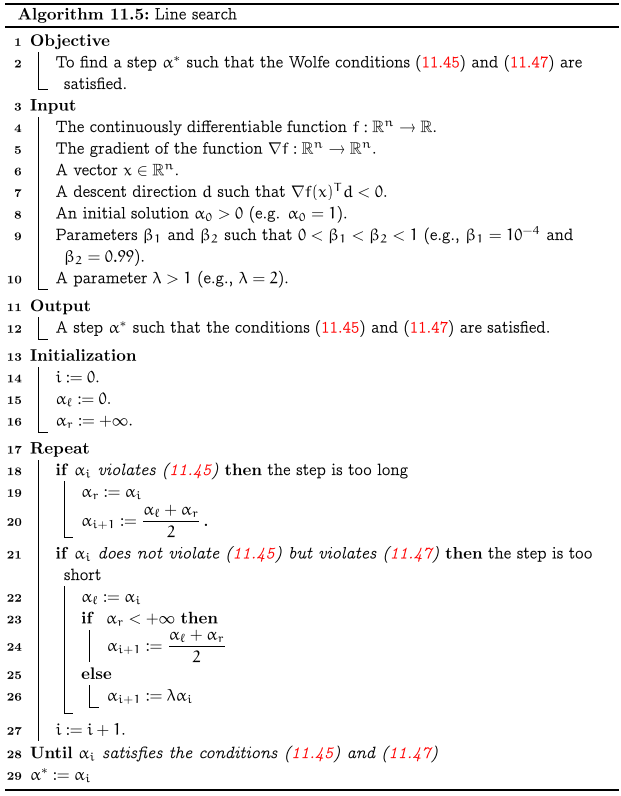

Example 11.2: $f(x) = \frac{1}{2} x_1^2 + \frac{9}{2} x_2^2$.

In [5]:
# Exemplo 11.2: f(x) = 2x1^2 + 2x2^2
f112(x) = 2*x[1]^2 + 2*x[2]^2
grad_f112(x) = [4*x[1], 4*x[2]]

function algoritmo_11_5(f, grad, x, d; alpha0=1.0, beta1=1e-4, beta2=0.9, lambda=2.0)
    alpha_low = 0.0
    alpha_high = Inf
    alpha = alpha0
    
    # Valores iniciais para as condições
    f0 = f(x)
    g0 = dot(grad(x), d)
    
    # Loop de busca (ajuste de intervalo)
    for i in 1:100
        fi = f(x + alpha * d)
        gi = dot(grad(x + alpha * d), d)
        
        # 1. Verifica Condição de Armijo (Decréscimo suficiente)
        if fi > f0 + beta1 * alpha * g0
            alpha_high = alpha
            alpha = (alpha_low + alpha_high) / 2
        
        # 2. Verifica Condição de Curvatura
        elseif gi < beta2 * g0
            alpha_low = alpha
            if isinf(alpha_high)
                alpha = alpha * lambda
            else
                alpha = (alpha_low + alpha_high) / 2
            end
        else
            # Ambas as condições satisfeitas (Wolfe)
            return alpha
        end
    end
    return alpha
end

# Teste rápido do Algoritmo 11.5
x_teste = [1.0, 1.0]
d_teste = -grad_f112(x_teste) # Direção de descida
alfa_otimo = algoritmo_11_5(f112, grad_f112, x_teste, d_teste)
println("Passo alfa encontrado pelo Algoritmo 11.5: ", alfa_otimo)

Passo alfa encontrado pelo Algoritmo 11.5: 0.25


### Algorithm 11.6: Steepest descent

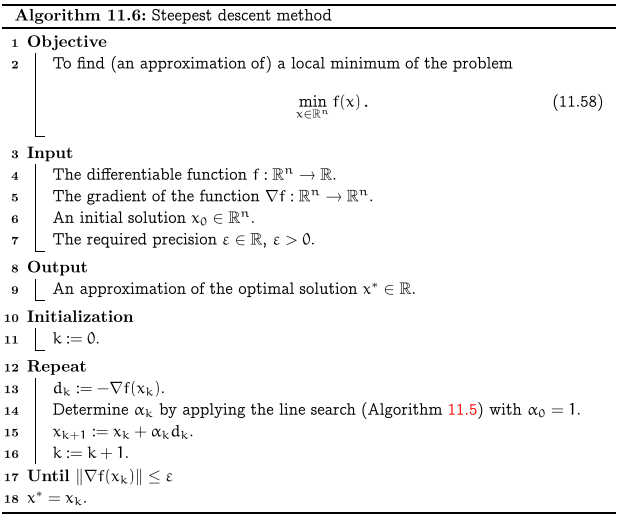

Test in the Rosenbrock function

In [9]:
using LinearAlgebra
using Printf

# --- Definições Necessárias para a Função de Rosenbrock ---
# (Repetindo aqui para evitar o erro de UndefVarError)
f_rosen(x) = sum([100*(x[i+1] - x[i]^2)^2 + (1 - x[i])^2 for i in 1:length(x)-1])

function rosenbrock_grad(x)
    n = length(x)
    g = zeros(n)
    for i in 1:n-1
        g[i] += -400*x[i]*(x[i+1] - x[i]^2) - 2*(1 - x[i])
        g[i+1] += 200*(x[i+1] - x[i]^2)
    end
    return g
end

# --- Implementação do Algoritmo 11.6 ---
function algoritmo_11_6(f, grad, x0, epsilon)
    xk = Float64.(x0)
    k = 0
    
    println("k    | ||grad f(xk)||      | alpha_k")
    println("-"^45)
    
    while norm(grad(xk)) > epsilon
        dk = -grad(xk)
        
        # Chamada para a busca linear (Algoritmo 11.5)
        ak = algoritmo_11_5(f, grad, xk, dk)
        
        xk = xk + ak * dk
        
        if k % 100 == 0
            @printf("%-4d | %-18.10e | %.4f\n", k, norm(grad(xk)), ak)
        end
        
        k += 1
        if k > 10000 
            println("\nLimite de 10.000 iterações atingido (comum no Gradiente Descendente).")
            break 
        end
    end
    
    @printf("\nConcluído em %d iterações.\n", k)
    @printf("Solução x*: %s\n", string(xk))
    @printf("Norma do gradiente final: %.2e\n", norm(grad(xk)))
    return xk
end

# --- Execução do Teste ---
x0_rosen = [1.2, 1.2]
resultado = algoritmo_11_6(f_rosen, rosenbrock_grad, x0_rosen, 1e-5)

k    | ||grad f(xk)||      | alpha_k
---------------------------------------------
0    | 3.0985565191e+01   | 0.0010
100  | 1.9741995771e-01   | 0.0039
200  | 2.3777175978e-01   | 0.0078
300  | 3.7728548718e-01   | 0.0156
400  | 1.7731932716e-01   | 0.0078
500  | 1.9904271071e-01   | 0.0156
600  | 1.4481351188e-01   | 0.0020
700  | 1.6651273188e-01   | 0.0020
800  | 2.0120453624e-01   | 0.0020
900  | 2.1651122651e-01   | 0.0020
1000 | 1.6772097512e-01   | 0.0020
1100 | 9.5901103850e-02   | 0.0020
1200 | 4.1963807952e-02   | 0.0020
1300 | 1.6108706613e-02   | 0.0020
1400 | 1.3258979309e-02   | 0.0020
1500 | 2.0726100041e-02   | 0.0020
1600 | 1.1882900931e-02   | 0.0020
1700 | 1.3444597504e-02   | 0.0020
1800 | 1.3453101246e-02   | 0.0020
1900 | 1.1775295583e-02   | 0.0020
2000 | 9.2128933255e-03   | 0.0020
2100 | 6.8021395947e-03   | 0.0020
2200 | 9.2745871360e-03   | 0.0020
2300 | 1.2775891367e-02   | 0.0039
2400 | 6.4771533087e-03   | 0.0020
2500 | 7.1559289823e-03   | 0.0020
2600 | 

2-element Vector{Float64}:
 1.0000090056728184
 1.0000180862511652